# 🚀 CrewAI + Groq Complete Notebook

## 📌 1. Install Dependencies

In [15]:
# !pip install crewai "crewai[tools]" "crewai[litellm]" --quiet

## 📌 2. Set Environment Variables

https://console.groq.com/keys

In [16]:
import os

# 🔑 Add your Groq API Key here
#os.environ["GROQ_API_KEY"] = "your_groq_api_key_here"
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

## 📌 3. Initialize Groq LLM

In [23]:
import crewai.llms.cache as _crewai_cache
_crewai_cache.mark_cache_breakpoint = lambda msg: msg

In [2]:
from crewai import LLM

llm = LLM(
    model="groq/llama-3.1-8b-instant",
    temperature=0.5,
    api_key=os.getenv("GROQ_API_KEY")
)



NameError: name 'os' is not defined

 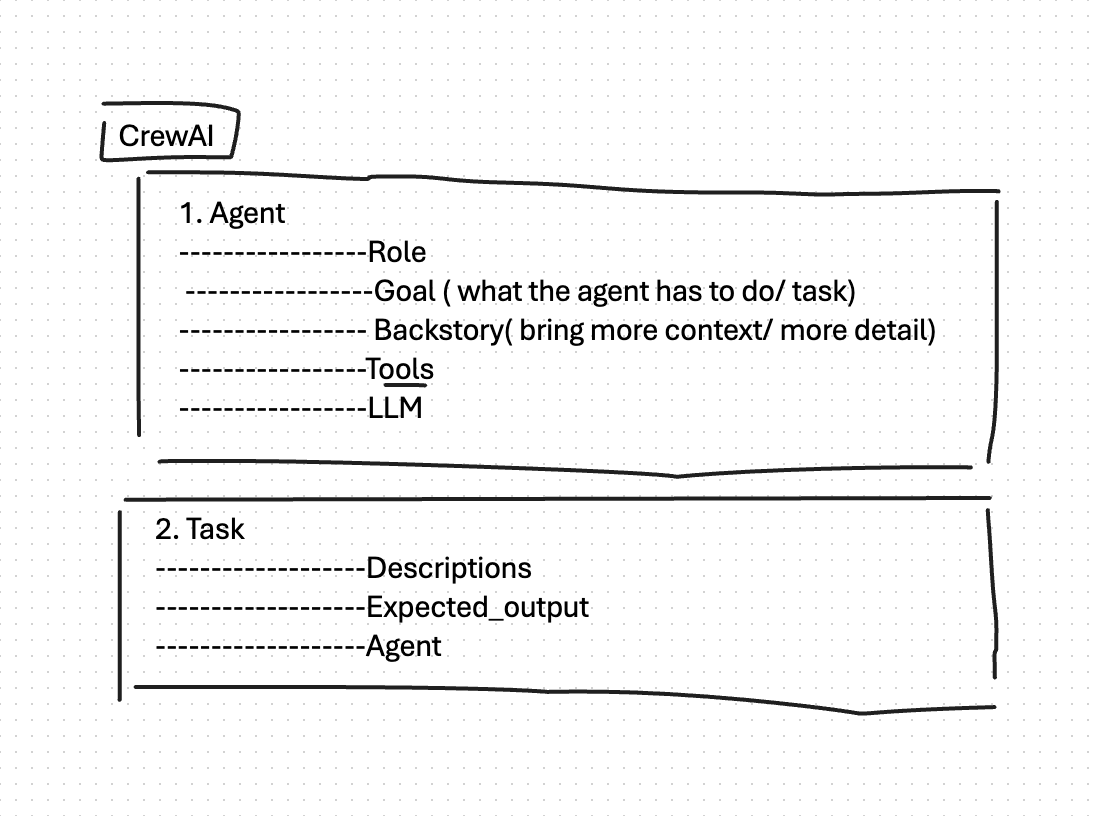

# Problem Statement – Multi-Agent AI System using CrewAI

## Overview

The given code defines a **multi-agent AI workflow** using the CrewAI framework.  
The objective is to create specialized AI agents that collaborate to perform complex tasks more efficiently.

In this example:

- One agent performs **research and information gathering**
- Another agent performs **content writing and presentation**

This follows the concept of **Agentic AI**, where multiple intelligent agents work together with defined roles, goals, and expertise.

---

# Problem Statement

Organizations often require AI systems that can:

- Research large amounts of information
- Extract meaningful insights
- Generate human-readable reports/articles
- Automate end-to-end knowledge workflows

Traditional single-LLM systems struggle because:

- One model performs all tasks without specialization
- Research quality and writing quality may vary
- Lack of role separation reduces accuracy and scalability
- Complex workflows become difficult to manage

To solve this problem, a **multi-agent architecture** is designed using CrewAI.

---

# Objective

Build a collaborative AI system where:

1. A **Research Agent** gathers accurate and relevant information.
2. A **Writer Agent** converts the research into clear, engaging, and structured content.
3. Both agents work together as a coordinated AI team.

---

# Code Explanation

## 1. Research Agent

```python
researcher = Agent(
    role="Senior Research Analyst",
    goal="Find accurate and relevant information",
    backstory="Expert in analyzing data and extracting insights",
    llm=llm,
    verbose=True
)

# 1. Research Agent

```python
researcher = Agent(
    role="Senior Research Analyst",
    goal="Find accurate and relevant information",
    backstory="Expert in analyzing data and extracting insights",
    llm=llm,
    verbose=True
)
```

## Purpose

This agent is responsible for:

- Research
- Data analysis
- Fact extraction
- Insight generation

---

## Components

| Parameter | Description |
|---|---|
| `role` | Defines the specialization of the agent |
| `goal` | Defines the main objective/task |
| `backstory` | Gives personality and expertise context to improve responses |
| `llm` | Large Language Model used by the agent |
| `verbose=True` | Displays detailed execution logs |

---

## Real-World Use Cases

- Market research
- Competitive analysis
- Financial analysis
- Legal document research
- Compliance investigation
- Scientific literature review

---

# 2. Writer Agent

```python
writer = Agent(
    role="Content Writer",
    goal="Write clear and engaging content",
    backstory="Skilled at turning research into readable articles",
    llm=llm,
    verbose=True
)
```

## Purpose

This agent converts research into:

- Articles
- Reports
- Summaries
- Blog posts
- Documentation

---

## Responsibilities

- Simplifying technical information
- Structuring content
- Improving readability
- Making content engaging

                +-------------------+
                |   User Request    |
                +-------------------+
                          |
                          v
              +----------------------+
              | Research Agent       |
              | (Data Collection)    |
              +----------------------+
                          |
                          v
              +----------------------+
              | Writer Agent         |
              | (Content Creation)   |
              +----------------------+
                          |
                          v
                +-------------------+
                | Final Output      |
                +-------------------+

## 📌 4. Create Agents

In [25]:
from crewai import Agent

researcher = Agent(
    role="Senior Research Analyst",
    goal="Find accurate and relevant information",
    backstory="Expert in analyzing data and extracting insights",
    llm=llm,
    verbose=True
)

writer = Agent(
    role="Content Writer",
    goal="Write clear and engaging content",
    backstory="Skilled at turning research into readable articles",
    llm=llm,
    verbose=True
)


## 📌 5. Define Tasks

In [26]:
from crewai import Task

research_task = Task(
    description="Research the impact of AI in banking sector",
    expected_output="Bullet points of key insights",
    agent=researcher
)

writing_task = Task(
    description="Write a blog based on the research findings",
    expected_output="Well-structured blog post",
    agent=writer
)


## 📌 6. Create Crew

In [27]:
from crewai import Crew

crew = Crew(
    agents=[researcher, writer],
    tasks=[research_task, writing_task],
    verbose=True
)


## 📌 7. Run the Workflow

In [28]:
#result = crew.kickoff()
result=crew.kickoff_async()
print(result)


<coroutine object Crew.kickoff_async at 0x7f4576da8b80>


/tmp/ipykernel_27500/3805492057.py:2: RuntimeWarning: coroutine 'Crew.kickoff_async' was never awaited
  result=crew.kickoff_async()


In [29]:
result = await crew.kickoff_async()
print(result.raw)

╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: 40fb7d74-74dc-48a0-8865-d768bf6a6a51                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name: Research the impact of AI in banking sector                                                              │
│  ID: cf61ec2e-0222-4a66-bafb-3e55c509c070                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Senior Research Analyst                                                                                 │
│                                                                                                                 │
│  Task: Research the impact of AI in banking sector                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

[Finalize] todos_count=0, todos_with_results=0


╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Senior Research Analyst                                                                                 │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  **Research Report: Impact of AI in the Banking Sector**                                                        │
│                                                                                                                 │
│  **Executive Summary**                                                                                          │
│                                                                                                                 │
│  The integration of Artificial Intelligence (AI) in the banking sector has been a significant trend in recent   │
│  years. The primary objective of this research is to analyze the impact of AI on the banking sector,            │
│  highlighting the benefits, challenges, and future prospects. Our research aims to provide insights into the    │
│  current state of AI adoption in banking, its applications, and the potential consequences on the industry.     │
│                                                                                                                 │
│  **Key Insights:**                                                                                              │
│                                                                                                                 │
│  * **Increased Efficiency:** AI has enabled banks to automate routine tasks, such as data entry, account        │
│  reconciliation, and customer service, resulting in increased efficiency and reduced costs.                     │
│  * **Improved Customer Experience:** AI-powered chatbots and virtual assistants have improved customer          │
│  experience by providing 24/7 support, personalized recommendations, and streamlined transactions.              │
│  * **Enhanced Risk Management:** AI has enabled banks to identify and mitigate risks more effectively, such as  │
│  credit risk, market risk, and operational risk, by analyzing vast amounts of data and identifying patterns.    │
│  * **Increased Security:** AI-powered systems have improved security by detecting and preventing cyber          │
│  threats, such as phishing and malware attacks, in real-time.                                                   │
│  * **Personalized Services:** AI has enabled banks to offer personalized services, such as tailored financial   │
│  advice, investment recommendations, and credit scoring, based on individual customer data.                     │
│  * **Increased Accuracy:** AI has improved the accuracy of financial transactions, such as payments and         │
│  transfers, by reducing errors and minimizing the risk of fraudulent activities.                                │
│  * **Challenges:** Despite the benefits, AI adoption in banking has also raised concerns about job              │
│  displacement, data privacy, and regulatory compliance.                                                         │
│  * **Future Prospects:** The future of AI in banking looks promising, with the potential for AI to              │
│  revolutionize the industry, improve customer experience, and drive business growth.                            │
│                                                                                                                 │
│  **Methodology**                                                                                                │
│                                                        

...

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name: Write a blog based on the research findings                                                              │
│  Agent: Content Writer                                                                                          │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

**The Impact of AI on the Banking Sector: A Comprehensive Analysis**

**Introduction**

The banking sector has undergone significant transformations in recent years, driven by the increasing adoption of Artificial Intelligence (AI). From automating routine tasks to improving customer experience, AI has revolutionized the way banks operate. In this blog post, we will delve into the impact of AI on the banking sector, highlighting the benefits, challenges, and future prospects.

**The Benefits of AI in Banking**

Our research has revealed that the adoption of AI in the banking sector has been driven by the need to improve efficiency, reduce costs, and enhance customer experience. The key benefits of AI in banking include:

* **Increased Efficiency:** AI has enabled banks to automate routine tasks, such as data entry, account reconciliation, and customer service, resulting in increased efficiency and reduced costs.
* **Improved Customer Experience:** AI-powered chatbots and virtual assist

/tmp/ipykernel_27500/2294953242.py:1: RuntimeWarning: coroutine 'Crew.kickoff_async' was never awaited
  result = await crew.kickoff_async()


╭─────────────────────────────────────────── Tracing Preference Saved ────────────────────────────────────────────╮
│                                                                                                                 │
│  Info: Tracing has been disabled.                                                                               │
│                                                                                                                 │
│  Your preference has been saved. Future Crew/Flow executions will not collect traces.                           │
│                                                                                                                 │
│  To enable tracing later, do any one of these:                                                                  │
│  • Set tracing=True in your Crew/Flow code                                                                      │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file                                                  │
│  • Run: crewai traces enable                                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: 40fb7d74-74dc-48a0-8865-d768bf6a6a51                                                                       │
│  Final Output: **The Impact of AI on the Banking Sector: A Comprehensive Analysis**                             │
│                                                                                                                 │
│  **Introduction**                                                                                               │
│                                                                                                                 │
│  The banking sector has undergone significant transformations in recent years, driven by the increasing         │
│  adoption of Artificial Intelligence (AI). From automating routine tasks to improving customer experience, AI   │
│  has revolutionized the way banks operate. In this blog post, we will delve into the impact of AI on the        │
│  banking sector, highlighting the benefits, challenges, and future prospects.                                   │
│                                                                                                                 │
│  **The Benefits of AI in Banking**                                                                              │
│                                                                                                                 │
│  Our research has revealed that the adoption of AI in the banking sector has been driven by the need to         │
│  improve efficiency, reduce costs, and enhance customer experience. The key benefits of AI in banking include:  │
│                                                                                                                 │
│  * **Increased Efficiency:** AI has enabled banks to automate routine tasks, such as data entry, account        │
│  reconciliation, and customer service, resulting in increased efficiency and reduced costs.                     │
│  * **Improved Customer Experience:** AI-powered chatbots and virtual assistants have improved customer          │
│  experience by providing 24/7 support, personalized recommendations, and streamlined transactions.              │
│  * **Enhanced Risk Management:** AI has enabled banks to identify and mitigate risks more effectively, such as  │
│  credit risk, market risk, and operational risk, by analyzing vast amounts of data and identifying patterns.    │
│  * **Increased Security:** AI-powered systems have improved security by detecting and preventing cyber          │
│  threats, such as phishing and malware attacks, in real-time.                                                   │
│  * **Personalized Services:** AI has enabled banks to offer personalized services, such as tailored financial   │
│  advice, investment recommendations, and credit scoring, based on individual customer data.                     │
│  * **Increased Accuracy:** AI has improved the accuracy of financial transactions, such as payments and         │
│  transfers, by reducing errors and minimizing the risk of fraudulent activities.                                │
│                                                                                                                 │
│  **The Challenges of AI Adoption in Banking**                                                                   │
│                                                                                                                 │
│  Despite the benefits, AI adoption in banking has also